In [2]:
import numpy as np
import cv2 as cv
cap = cv.VideoCapture(0)
if not cap.isOpened():
    print("Cannot open camera")
    exit()
while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    # if frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break
    # Our operations on the frame come here
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    # Display the resulting frame
    cv.imshow('frame', gray)
    if cv.waitKey(1) == ord('q'):
        break
# When everything done, release the capture
cap.release()
cv.destroyAllWindows()


In [ ]:
import psutil

# List of commonly known camera-using applications (example list, extend as needed)
camera_apps = [
    'Skype.exe', 'zoom.exe', 'Teams.exe', 'chrome.exe', 'firefox.exe', # Previously mentioned
    'Webex.exe', 'slack.exe', 'WhatsApp.exe', 'GoogleMeet.exe',       # Additional conferencing tools
    'OBS.exe', 'XSplit.exe',                                          # Streaming and recording
    'CameraApp.exe', 'PhotoBooth.exe',                                # System camera apps
    'SnapCamera.exe', 'Facetime.exe',                                 # Social and camera filter apps
    'Discord.exe', 'Telegram.exe',                                    # Social messaging apps with video capabilities
    'BlueJeans.exe',                                                  # More conferencing tools
    'AdobePremierePro.exe', 'AfterEffects.exe',                       # Video editing software that might access the camera
    'VLC.exe', 'QuickTimePlayer.exe',                                 # Media players that can capture from camera
    'GotoMeeting.exe'                                                 # Another conferencing tool
]

def kill_camera_apps(camera_apps):
    killed_apps = []
    for process in psutil.process_iter(attrs=['pid', 'name']):
        if process.info['name'] in camera_apps:
            try:
                process.terminate()  # or process.kill() for a forceful kill
                killed_apps.append(process.info['name'])
                print(f"Terminated: {process.info['name']} (PID: {process.info['pid']})")
            except (psutil.NoSuchProcess, psutil.AccessDenied, psutil.ZombieProcess) as e:
                print(f"Failed to terminate {process.info['name']} (PID: {process.info['pid']}): {e}")
    return killed_apps

def main():
    killed_apps = kill_camera_apps(camera_apps)
    if not killed_apps:
        print("No known camera-using applications were running.")
    else:
        print(f"Terminated applications: {', '.join(killed_apps)}")

if __name__ == "__main__":
    main()


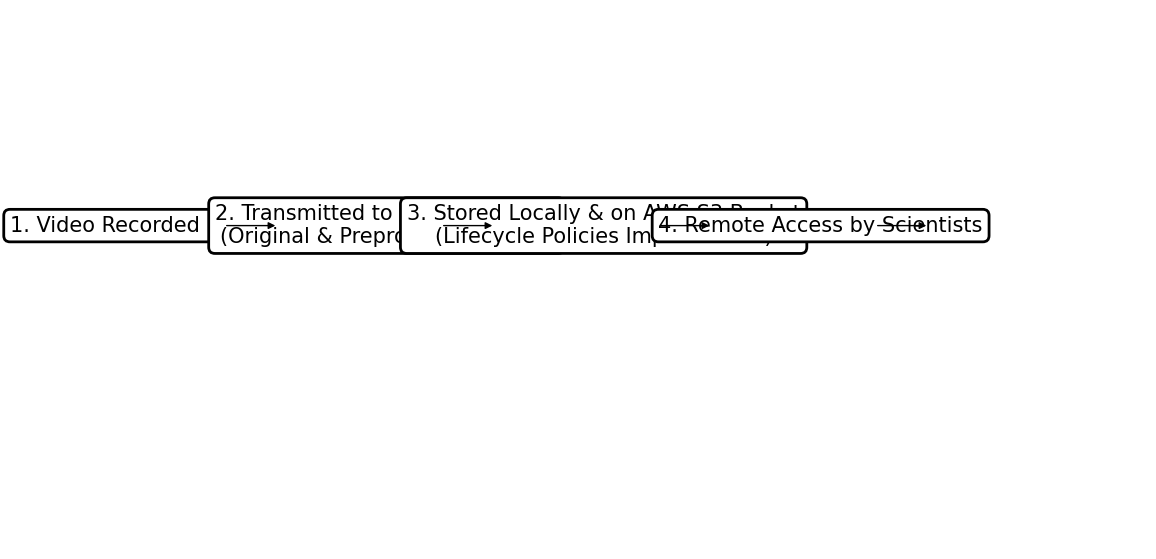

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 7))

# Hide axes
ax.axis('off')

bbox_props = dict(boxstyle="round,pad=0.3", ec="black", lw=2, fc="white")

# Stage 1: Video Recorded Underwater
ax.text(0.1, 0.6, "1. Video Recorded Underwater", ha="center", va="center", size=15,
        bbox=bbox_props)

# Stage 2: Transmitted to Outer Operator
ax.text(0.3, 0.6, "2. Transmitted to Outer Operator\n(Original & Preprocessed Video)", ha="center", va="center", size=15,
        bbox=bbox_props)

# Stage 3: Stored Locally & on AWS S3 Bucket
ax.text(0.5, 0.6, "3. Stored Locally & on AWS S3 Bucket\n(Lifecycle Policies Implemented)", ha="center", va="center", size=15,
        bbox=bbox_props)

# Stage 4: Remote Access by Scientists
ax.text(0.7, 0.6, "4. Remote Access by Scientists", ha="center", va="center", size=15,
        bbox=bbox_props)

# Connections
arrow_props = dict(facecolor="black", arrowstyle="-|>", lw=1)
ax.annotate("", xy=(0.2, 0.6), xytext=(0.15, 0.6), arrowprops=arrow_props)
ax.annotate("", xy=(0.4, 0.6), xytext=(0.35, 0.6), arrowprops=arrow_props)
ax.annotate("", xy=(0.6, 0.6), xytext=(0.55, 0.6), arrowprops=arrow_props)
ax.annotate("", xy=(0.8, 0.6), xytext=(0.75, 0.6), arrowprops=arrow_props)

plt.show()
